# Parameter setzen:

In [ ]:
import os
import numpy as np
import sys

# GPU wählen
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

# Run-Config
model = "Sims_fx_no_tmppca" #Sims_fx_no_tmppca
batch_size = 600

model_input = "../datasets/Simulated_Lesion_double_6_normalized_tMPPCA_5D/data.npy"  #
GT_path = "../datasets/Simulated_Lesion_GT_double_normalized/data.npy"

# ---- Comparisons definieren ----
comparison_paths = [
    model_input,
    GT_path,
]

Titles = [
    "Deep",
    "No Denoising",
    "GT",
]

# ---- Daten laden (einmalig!) ----
Data = [np.load(p) for p in comparison_paths]

# Inference

In [2]:
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

from denoising.config.load import load_yaml
from denoising.config.build import build_config
from denoising.inference.api import infer
from src.denoising.figures.EvalBeforeFitting import *

config_path = f"../trained_models/{model}/train.yaml"

cfg = build_config(load_yaml(config_path))

denoised, meta = infer(
    cfg=cfg,
    ckpt_path=f"../trained_models/{model}/checkpoints/last.pt",
    input_path=model_input,   # exakter Pfad zur Datei
    batch_size=batch_size
)

Data.insert(0, denoised)

# auch fft
Data_ft = [np.fft.fftshift(np.fft.fft(d, axis=3), axes=3) for d in Data]

# Optional als matlab datei speichern

In [3]:
# from scipy.io import loadmat, savemat

# #savemat('sf_brain_DMI_HC_pilot_deep_only.mat', {'Data': out_data})

# # Für SIMS:

# ### CAREFUL DISTINGUISH BETWEEN LESION AND NO LESION

# #/Lade Par und mask aus der B0_1.mat-Datei
# b0_data = loadmat('../datasets/Simulated_Lesion_GT/Lesion_120pts.mat')  #Simulated_Lesion_GT/Lesion_120pts.mat  Simulated_ground_truth/B0_1.mat
# par = b0_data['csi_data_lr']['Par'][0, 0]
# mask = b0_data['csi_data_lr']['mask'][0, 0]

# # Deine Datensätze
# data_dicts = {
#     f'Lesion_double_deep_tmppca_6_retrained.mat': denoised
#     #f'Lesion_double_deep_noisy_6_uncorrelated.mat': noisy_data
#     #'Lesion_gt.mat': tgt_data
# }

# # Für jede Datei speichern
# for filename, data in data_dicts.items():
#     savemat(filename, {
#         'csi_data_lr': {
#             'Data': data,
#             'Par': par,
#             'mask': mask
#         }
#     })

# Compare FID

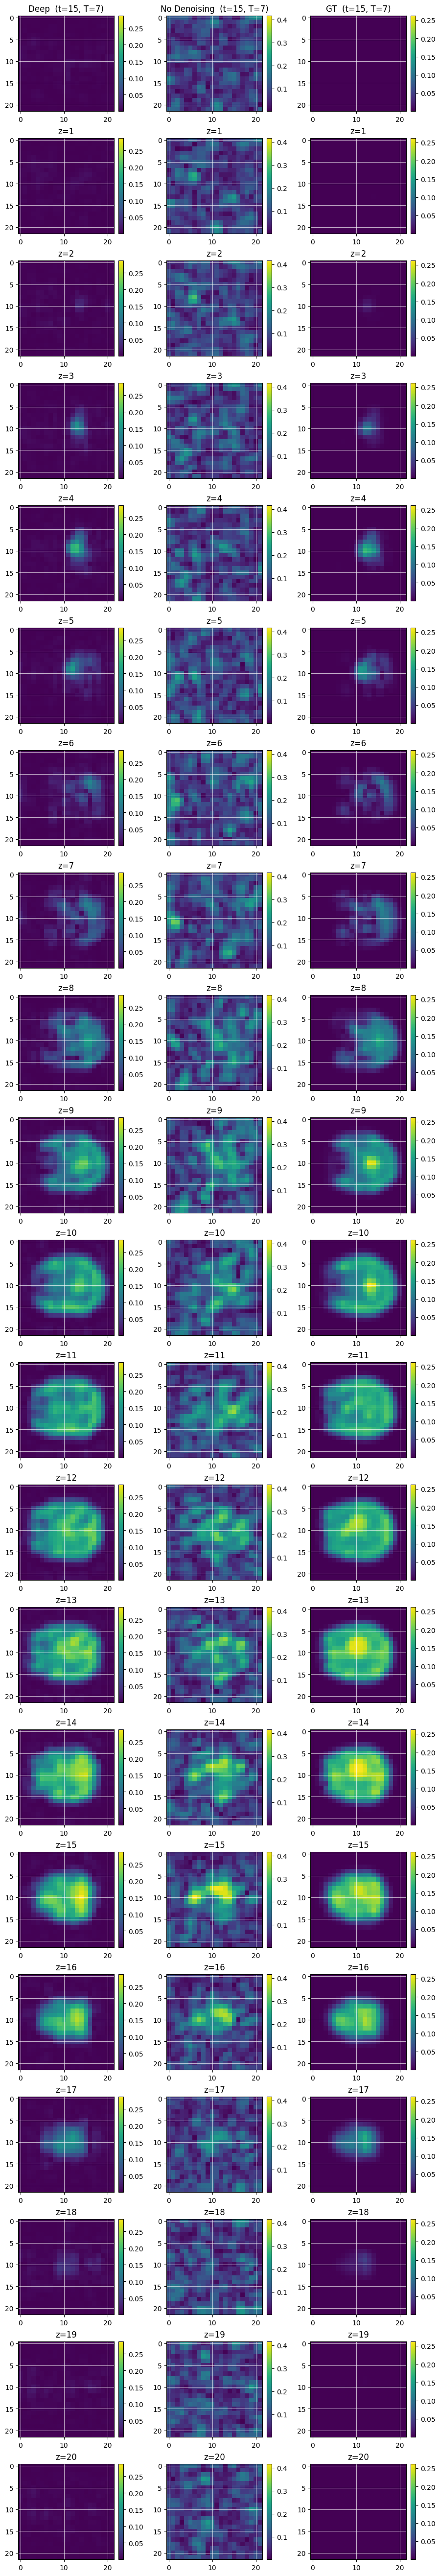

In [4]:
fig, axes = plot_z_slices(
    Data,
    Titles,
    t=15,
    T=7,
    share_clim="per_column",
)

plt.show()

# Compare Spectra

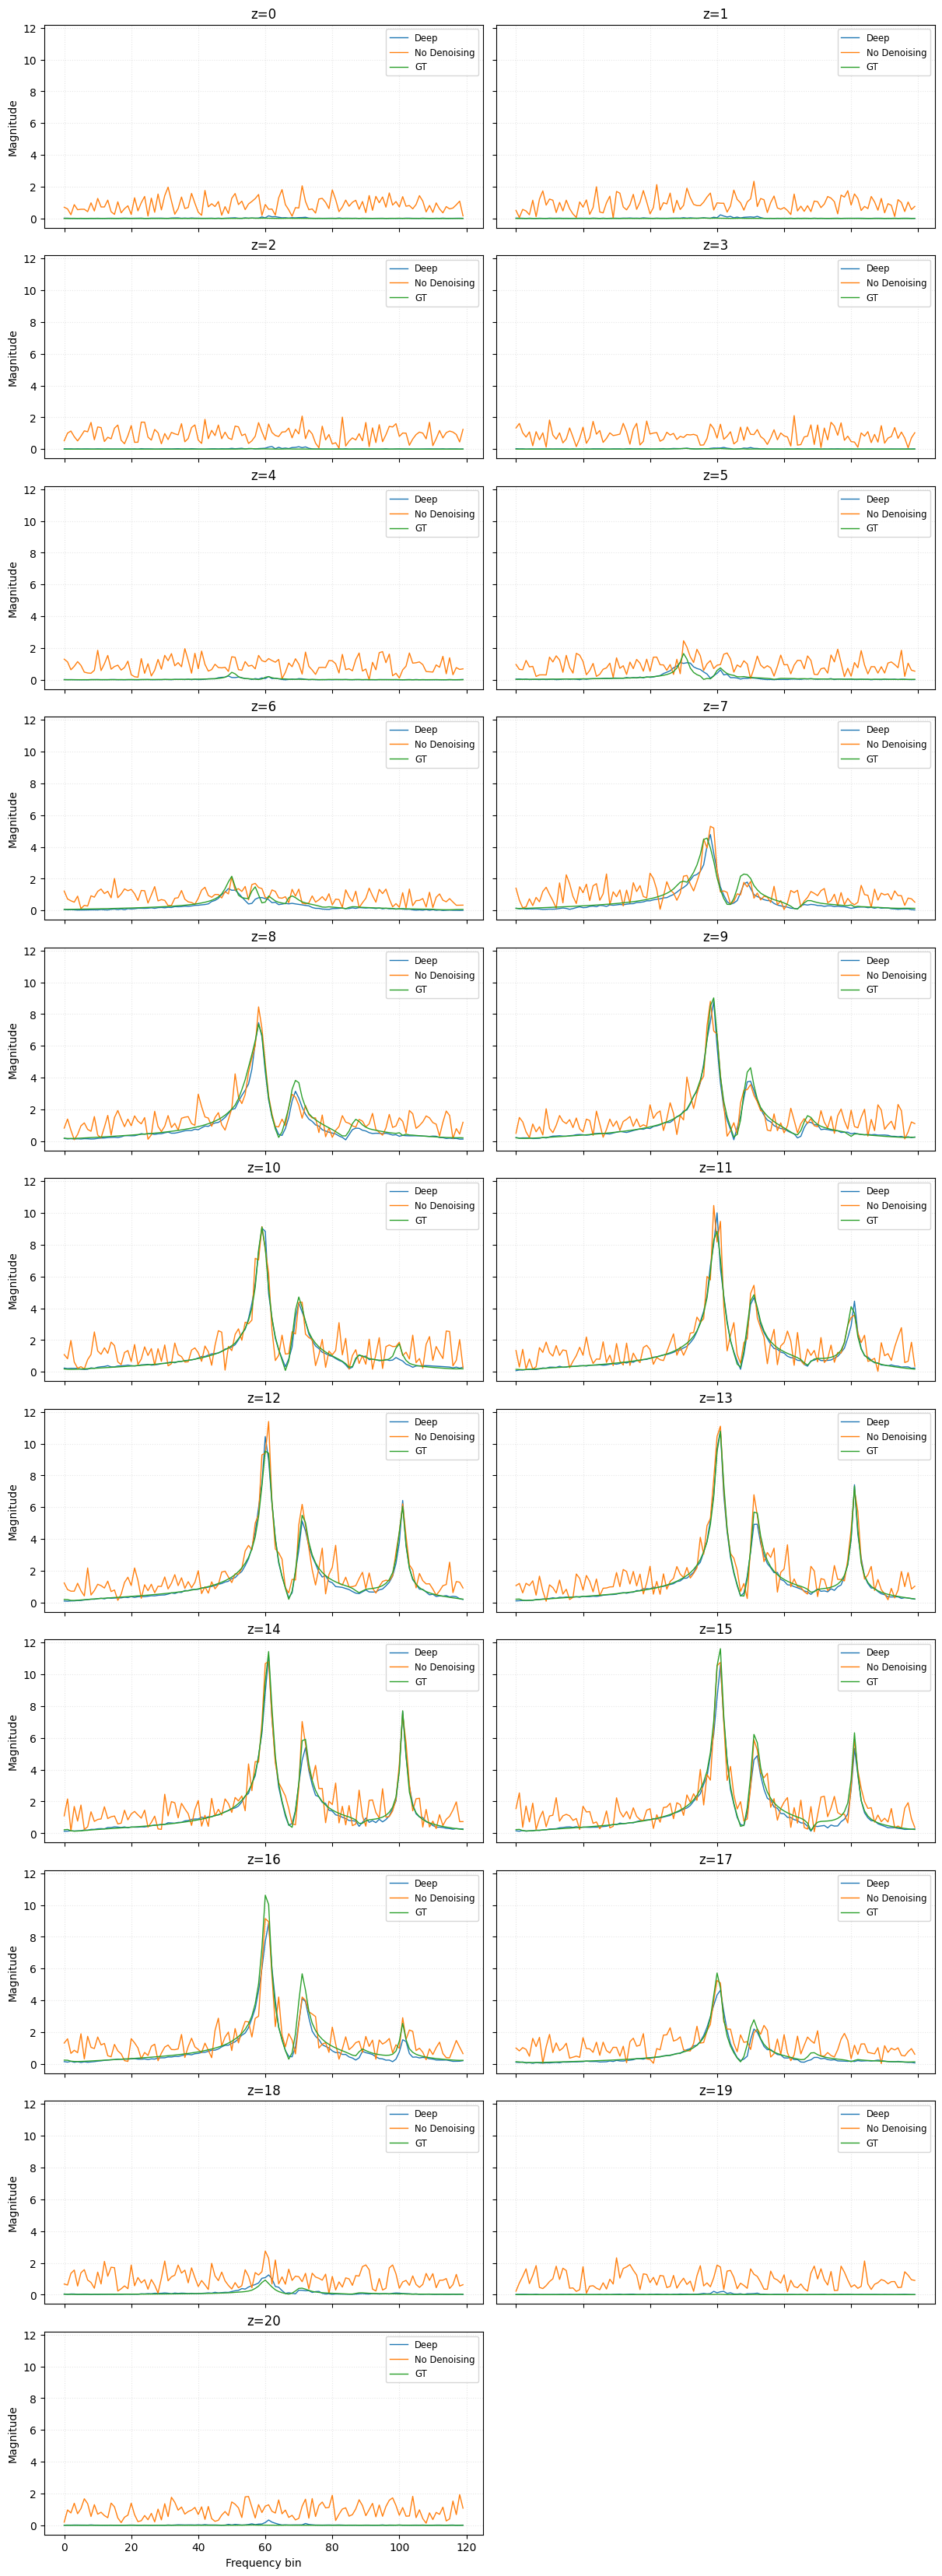

In [5]:
_ = plot_voxel_spectra_over_z(Data_ft, Titles, x=8, y=10, T=7, z_max=21)

plt.show()

# Compare spectral peaks

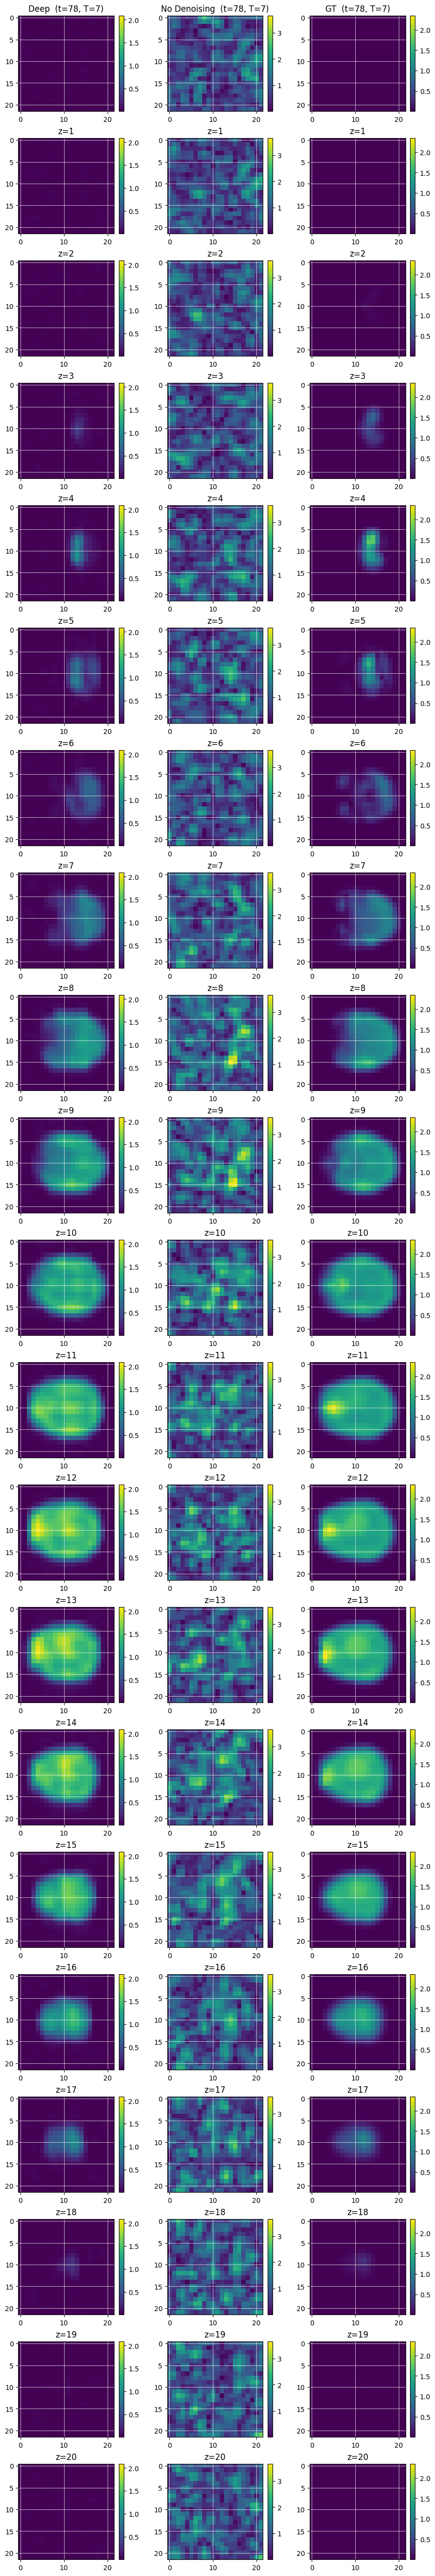

In [6]:
fig, axes = plot_z_slices(
    Data_ft,
    Titles,
    t=78,  #78 ca Glx
    T=7,
    share_clim="per_column",
)

plt.show()

# Compare average spectra
Here I compare the average spectrum over time (which is a high SNR estimate)

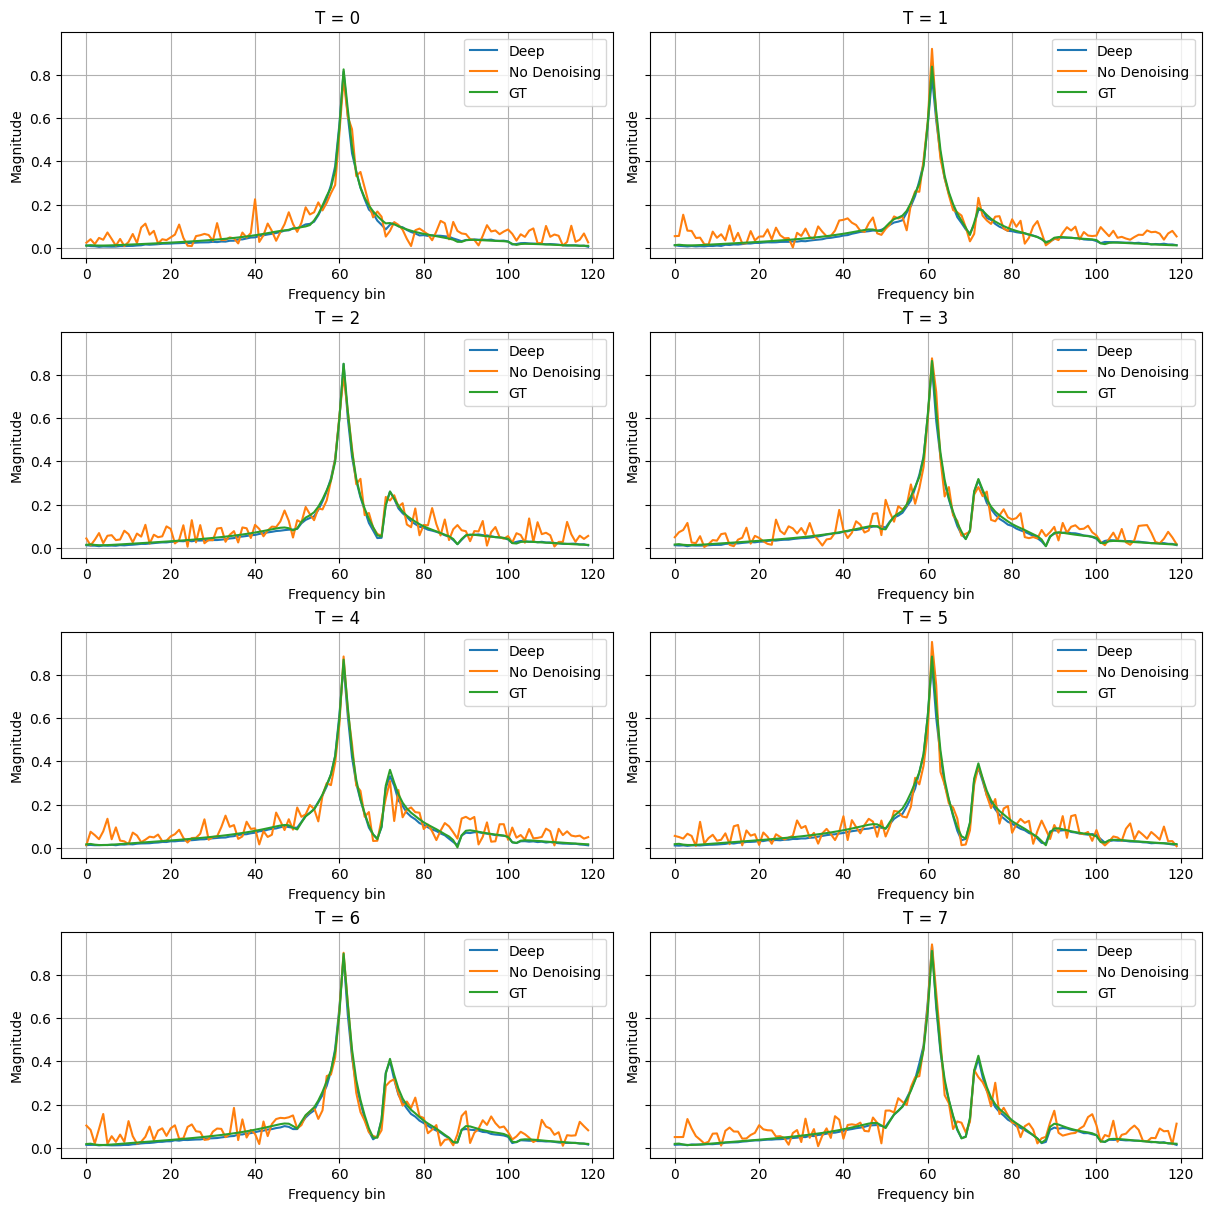

In [7]:
Avg = [np.mean(d, axis=(0,1,2)) for d in Data_ft]

_ = plot_average_spectra_over_T(
    Avg,
    Titles,
    n_cols=2,
)
plt.show()